In [34]:
# MVC Project: Multilayer Perceptron
# Task 7 — Python Implementation on MNIST

# Roll No: 25I-3075
# Section: SE-D
# University: National University of Computer and Emerging Sciences

"""
Network Architecture (MNIST):
| Layer   | Type     | Neurons | Activation |
|---------|----------|---------|------------|
| Layer 0 | Input    | 784     | —          |
| Layer 1 | Hidden 1 | 128     | Sigmoid    |
| Layer 2 | Hidden 2 | 64      | Sigmoid    |
| Layer 3 | Output   | 10      | Sigmoid    |
"""
print("Notebook initialized for Roll No: 25I-3075")

Notebook initialized for Roll No: 25I-3075


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import os, urllib.request, gzip, struct
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print('Libraries loaded successfully.')
print(f'NumPy version: {np.__version__}')

Libraries loaded successfully.
NumPy version: 2.0.2


In [44]:
def download_mnist():
    """Download MNIST dataset if not present and return arrays."""
    if os.path.exists('mnist.npz'):
        print('Loading mnist.npz ...')
        data = np.load('mnist.npz')
        return (data['x_train'], data['y_train'], data['x_test'],  data['y_test'])

    try:
        from tensorflow.keras.datasets import mnist
        (X_train, Y_train), (X_test, Y_test) = mnist.load_data()
        print('Loaded MNIST via Keras.')
        return X_train, Y_train, X_test, Y_test
    except Exception:
        pass

    try:
        from sklearn.datasets import fetch_openml
        print('Downloading MNIST via sklearn (may take a moment)...')
        mnist_sk = fetch_openml('mnist_784', version=1, as_frame=False)
        X = mnist_sk.data.astype(np.float32)
        Y = mnist_sk.target.astype(int)
        X_train, X_test = X[:60000], X[60000:]
        Y_train, Y_test = Y[:60000], Y[60000:]
        X_train = X_train.reshape(-1, 28, 28)
        X_test  = X_test.reshape(-1, 28, 28)
        return X_train, Y_train, X_test, Y_test
    except Exception:
        pass

    raise RuntimeError('Could not load MNIST. Please ensure internet connection or mnist.npz file.')

X_train_raw, Y_train, X_test_raw, Y_test = download_mnist()

# Flatten and normalize
X_train = X_train_raw.reshape(-1, 784).astype(np.float32) / 255.0
X_test  = X_test_raw.reshape(-1, 784).astype(np.float32)  / 255.0
Y_train = Y_train.astype(int)
Y_test  = Y_test.astype(int)

def one_hot(y, num_classes=10):
    m = y.shape[0]
    Y_oh = np.zeros((m, num_classes), dtype=np.float32)
    Y_oh[np.arange(m), y] = 1.0
    return Y_oh

Y_train_oh = one_hot(Y_train)
Y_test_oh  = one_hot(Y_test)

print(f'X_train shape : {X_train.shape}')
print(f'Y_train shape : {Y_train.shape}')





Loaded MNIST via Keras.
X_train shape : (60000, 784)
Y_train shape : (60000,)


In [46]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1.0 - a)

# Quick verification
test_z = np.array([-2.0, 0.0, 2.0])
print('Sigmoid test:', np.round(sigmoid(test_z), 4))

Sigmoid test: [0.1192 0.5    0.8808]


In [38]:
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)
    return Z1, A1, Z2, A2, Z3, A3

def mse_loss(Y_true, Y_pred):
    return float(np.mean((Y_true - Y_pred) ** 2))

def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):
    m = X.shape[0]
    # Layer 3
    delta3 = -2.0 * (Y_true - A3) * sigmoid_derivative(A3)
    dW3 = (A2.T @ delta3) / m
    db3 = np.mean(delta3, axis=0, keepdims=True)
    # Layer 2
    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)
    dW2 = (A1.T @ delta2) / m
    db2 = np.mean(delta2, axis=0, keepdims=True)
    # Layer 1
    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)
    dW1 = (X.T @ delta1) / m
    db1 = np.mean(delta1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2, dW3, db3

In [50]:
def update_weights(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, learning_rate):
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3
    return W1, b1, W2, b2, W3, b3

# Initialisation
np.random.seed(42)
W1 = np.random.uniform(-0.5, 0.5, (784, 128)).astype(np.float32)
b1 = np.zeros((1, 128), dtype=np.float32)
W2 = np.random.uniform(-0.5, 0.5, (128, 64)).astype(np.float32)
b2 = np.zeros((1, 64), dtype=np.float32)
W3 = np.random.uniform(-0.5, 0.5, (64, 10)).astype(np.float32)
b3 = np.zeros((1, 10), dtype=np.float32)

print(f'Total parameters: {(W1.size + b1.size + W2.size + b2.size + W3.size + b3.size):,}')



Total parameters: 109,386


In [51]:
learning_rate = 0.1
epochs = 20
batch_size = 32
loss_history = []
train_acc_history = []

for epoch in range(epochs):
    idx = np.random.permutation(X_train.shape[0])
    X_shuf, Y_shuf = X_train[idx], Y_train_oh[idx]

    for start in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuf[start : start + batch_size]
        Y_batch = Y_shuf[start : start + batch_size]

        Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_batch, W1, b1, W2, b2, W3, b3)
        grads = backpropagation(X_batch, Y_batch, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3)
        W1, b1, W2, b2, W3, b3 = update_weights(W1, b1, W2, b2, W3, b3, *grads, learning_rate)

    _, _, _, _, _, A3_full = forward_pass(X_train, W1, b1, W2, b2, W3, b3)
    epoch_loss = mse_loss(Y_train_oh, A3_full)
    loss_history.append(epoch_loss)
    train_acc = np.mean(np.argmax(A3_full, axis=1) == Y_train) * 100
    train_acc_history.append(train_acc)
    print(f'Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.5f} - Acc: {train_acc:.2f}%')

Epoch 1/20 - Loss: 0.02957 - Acc: 84.95%
Epoch 2/20 - Loss: 0.02078 - Acc: 88.86%
Epoch 3/20 - Loss: 0.01723 - Acc: 90.28%
Epoch 4/20 - Loss: 0.01530 - Acc: 91.28%
Epoch 5/20 - Loss: 0.01381 - Acc: 92.02%
Epoch 6/20 - Loss: 0.01271 - Acc: 92.66%
Epoch 7/20 - Loss: 0.01188 - Acc: 93.16%
Epoch 8/20 - Loss: 0.01114 - Acc: 93.61%
Epoch 9/20 - Loss: 0.01054 - Acc: 94.00%
Epoch 10/20 - Loss: 0.01001 - Acc: 94.28%
Epoch 11/20 - Loss: 0.00954 - Acc: 94.57%
Epoch 12/20 - Loss: 0.00912 - Acc: 94.77%
Epoch 13/20 - Loss: 0.00879 - Acc: 95.01%
Epoch 14/20 - Loss: 0.00841 - Acc: 95.25%
Epoch 15/20 - Loss: 0.00811 - Acc: 95.34%
Epoch 16/20 - Loss: 0.00783 - Acc: 95.54%
Epoch 17/20 - Loss: 0.00764 - Acc: 95.64%
Epoch 18/20 - Loss: 0.00732 - Acc: 95.86%
Epoch 19/20 - Loss: 0.00714 - Acc: 95.95%
Epoch 20/20 - Loss: 0.00689 - Acc: 96.09%


Final Test Accuracy: 95.54%


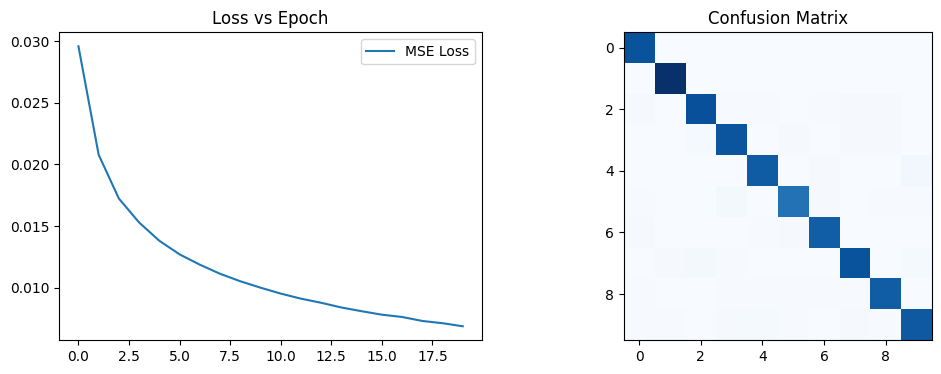

In [52]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history, label='MSE Loss')
plt.title('Loss vs Epoch')
plt.legend()

# Test Accuracy
_, _, _, _, _, A3_test = forward_pass(X_test, W1, b1, W2, b2, W3, b3)
preds_test = np.argmax(A3_test, axis=1)
test_acc = np.mean(preds_test == Y_test) * 100
print(f'Final Test Accuracy: {test_acc:.2f}%')

# Confusion Matrix
conf_matrix = np.zeros((10, 10), dtype=int)
for true, pred in zip(Y_test, preds_test):
    conf_matrix[true, pred] += 1
plt.subplot(1, 2, 2)
plt.imshow(conf_matrix, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

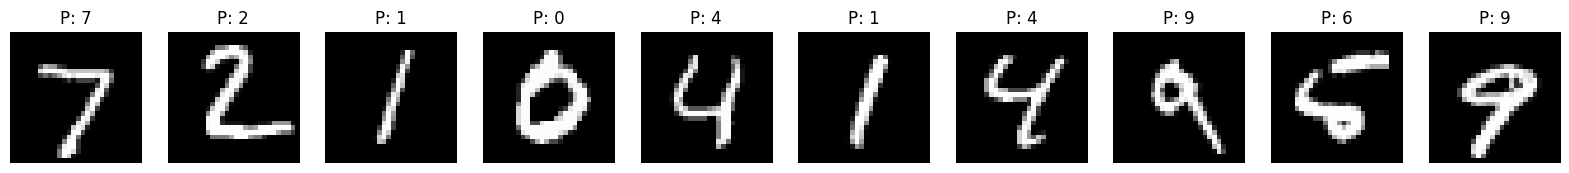

In [53]:
fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    axes[i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'P: {preds_test[i]}')
    axes[i].axis('off')
plt.show()